In [1]:

# Core imports for the whole lab
import numpy as np
import numpy.linalg as la          # inv, norm, eig, solve, matrix_rank
import matplotlib.pyplot as plt

np.set_printoptions(precision=3, suppress=True)   # tidy array printing
np.random.seed(42)
print('Setup complete. NumPy', np.__version__)

Setup complete. NumPy 2.0.2


In [4]:
# -----------------------------------------------------------
# 🔹 1A. THE FOUR CONTAINERS
# -----------------------------------------------------------

scalar = np.array(5)                  # 0-D: a single number
vector = np.array([2, 5, 1])          # 1-D: a list of numbers
matrix = np.array([[1, 2], [3, 4]])   # 2-D: rows x columns
tensor = np.ones((3, 2, 2))           # n-D: a stack of matrices

# .ndim = number of dimensions, .shape = size along each dimension
for name, arr in [('scalar', scalar), ('vector', vector),
                  ('matrix', matrix), ('tensor', tensor)]:
    print(f'{name:7s} ndim={arr.ndim}  shape={arr.shape}')


scalar  ndim=0  shape=()
vector  ndim=1  shape=(3,)
matrix  ndim=2  shape=(2, 2)
tensor  ndim=3  shape=(3, 2, 2)


In [5]:
# -----------------------------------------------------------
# 🔹 1B. TENSOR OPERATIONS: add, transpose, reshape
# -----------------------------------------------------------

A = np.arange(6).reshape(2, 3)   # shape (2, 3)
B = np.ones((2, 3), dtype=int)

print('A:\n', A)
print('A + B (element-wise add):\n', A + B)
print('A.T  (transpose -> shape', A.T.shape, '):\n', A.T)
print('A.reshape(3, 2):\n', A.reshape(3, 2))
print('A.flatten():', A.flatten())

A:
 [[0 1 2]
 [3 4 5]]
A + B (element-wise add):
 [[1 2 3]
 [4 5 6]]
A.T  (transpose -> shape (3, 2) ):
 [[0 3]
 [1 4]
 [2 5]]
A.reshape(3, 2):
 [[0 1]
 [2 3]
 [4 5]]
A.flatten(): [0 1 2 3 4 5]


In [10]:

T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
# YOUR CODE HERE
s = np.ones((3,4), dtype=int)
print("T:\n", T)
# 2. T + T
# YOUR CODE HERE

print("T + s (elements wise add):\n", T + s)


# 3. Transpose (print .T.shape) and reshape to (2, 6)
# YOUR CODE HERE

print('T.s (transpose -> shape', T.s.shape, '):\n', T.s)
print("T,reshape(2,6):\n", T.reshape(2,6))
print("T.flatten()", T.flatten)

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
T + s (elements wise add):
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]


AttributeError: 'numpy.ndarray' object has no attribute 's'

In [15]:

T = np.arange(12).reshape(3, 4)
print('T:\n', T)

# 1. ndim and shape
# YOUR CODE HERE
s = np.ones((3,4), dtype=int)
print("T:\n", T)
# 2. T + T
# YOUR CODE HERE

print("T + s (elements wise add):\n", T + s)


# 3. Transpose (print .T.shape) and reshape to (2, 6)
# YOUR CODE HERE

print('T.T (transpose -> shape', T.T.shape, '):\n', T.T)
print("T,reshape(2,6):\n", T.reshape(2,6))
print("T.flatten()", T.flatten)

T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
T:
 [[ 0  1  2  3]
 [ 4  5  6  7]
 [ 8  9 10 11]]
T + s (elements wise add):
 [[ 1  2  3  4]
 [ 5  6  7  8]
 [ 9 10 11 12]]
T.T (transpose -> shape (4, 3) ):
 [[ 0  4  8]
 [ 1  5  9]
 [ 2  6 10]
 [ 3  7 11]]
T,reshape(2,6):
 [[ 0  1  2  3  4  5]
 [ 6  7  8  9 10 11]]
T.flatten() <built-in method flatten of numpy.ndarray object at 0x7838779e25b0>


In [16]:
# -----------------------------------------------------------
# 🔹 2A. DOT & CROSS PRODUCTS
# -----------------------------------------------------------

a = np.array([1, 2, 3])
b = np.array([4, 0, 1])

# Dot product: sum of element-wise products -> measures alignment
print('a . b  (dot)   :', np.dot(a, b))      # 1*4 + 2*0 + 3*1 = 7

# Cross product: a new vector perpendicular to both (3-D only)
print('a x b  (cross) :', np.cross(a, b))

a . b  (dot)   : 7
a x b  (cross) : [ 2 11 -8]


In [28]:
# -----------------------------------------------------------
# 🔹 2B. NORMS (vector length) + COSINE SIMILARITY
# -----------------------------------------------------------

print('L2 norm  ||a||_2 :', la.norm(a))         # sqrt(sum of squares)
print('L1 norm  ||a||_1 :', la.norm(a, 1))      # sum of absolute values
print('Linf norm        :', la.norm(a, np.inf)) # max absolute value

# Cosine similarity: the angle between vectors, ignoring magnitude
def cosine(u, v):
    # Handle cases where one or both vectors might be zero to avoid division by zero
    norm_u = la.norm(u)
    norm_v = la.norm(v)
    if norm_u == 0 or norm_v == 0:
        return 0.0 # Or raise an error, depending on desired behavior for zero vectors
    return np.dot(u, v) / (norm_u * norm_v)

print('cosine(a, b)     :', round(cosine(a, b), 3))

# Function to find the most similar pair from a list of pairs
def find_most_similar_pair(pair_list):
    max_similarity = -2.0  # Cosine similarity ranges from -1 to 1, so -2 is a safe initial minimum
    most_similar_pair_index = -1
    for i, (u, v) in enumerate(pair_list):
        similarity = cosine(u, v) # Use the cosine function defined above
        if similarity > max_similarity:
            max_similarity = similarity
            most_similar_pair_index = i
    return most_similar_pair_index, max_similarity


L2 norm  ||a||_2 : 3.7416573867739413
L1 norm  ||a||_1 : 6.0
Linf norm        : 3.0
cosine(a, b)     : 0.454


In [30]:
pairs = [
    (np.array([1, 0, 1]), np.array([1, 0, 1])),    # pair 1
    (np.array([1, 2, 3]), np.array([3, 2, 1])),    # pair 2
    (np.array([2, 0, 0]), np.array([0, 5, 0])),    # pair 3
]

similarities = []
for i, (u, v) in enumerate(pairs, start=1):
    print(f'\n--- Pair {i} ---')
    # 1. L1 and L2 norm of u
    print(f'L1 norm ||u||_1: {la.norm(u, 1):.3f}')
    print(f'L2 norm ||u||_2: {la.norm(u):.3f}')
    print(f'L1 norm ||v||_1: {la.norm(v, 1):.3f}')
    print(f'L2 norm ||v||_2: {la.norm(v):.3f}')

    # 2. cosine similarity of u and v
    current_similarity = cosine(u, v);
    print(f'cosine(u, v): {current_similarity:.3f}')
    similarities.append(current_similarity)

# 3. Most similar pair
most_similar_pair_index, max_similarity = find_most_similar_pair(pairs)
# Adjust index to be 1-based for display
print(f'\n3. Most similar pair is pair {most_similar_pair_index + 1} with cosine similarity: {max_similarity:.3f}')



--- Pair 1 ---
L1 norm ||u||_1: 2.000
L2 norm ||u||_2: 1.414
L1 norm ||v||_1: 2.000
L2 norm ||v||_2: 1.414
cosine(u, v): 1.000

--- Pair 2 ---
L1 norm ||u||_1: 6.000
L2 norm ||u||_2: 3.742
L1 norm ||v||_1: 6.000
L2 norm ||v||_2: 3.742
cosine(u, v): 0.714

--- Pair 3 ---
L1 norm ||u||_1: 2.000
L2 norm ||u||_2: 2.000
L1 norm ||v||_1: 5.000
L2 norm ||v||_2: 5.000
cosine(u, v): 0.000

3. Most similar pair is pair 1 with cosine similarity: 1.000


In [31]:
# -----------------------------------------------------------
# 🔹 3A. CORE MATRIX OPERATIONS
# -----------------------------------------------------------

A = np.array([[2., 1.],
              [1., 3.]])
B = np.array([[1., 0.],
              [4., 2.]])

print('A @ B (matrix multiply):\n', A @ B)
print('A.T   (transpose):\n', A.T)
print('inverse(A):\n', la.inv(A))
print('trace(A) = sum of diagonal:', np.trace(A))

A @ B (matrix multiply):
 [[ 6.  2.]
 [13.  6.]]
A.T   (transpose):
 [[2. 1.]
 [1. 3.]]
inverse(A):
 [[ 0.6 -0.2]
 [-0.2  0.4]]
trace(A) = sum of diagonal: 5.0


In [32]:
# -----------------------------------------------------------
# 🔹 3B. SPECIAL MATRICES: identity, symmetric, orthogonal
# -----------------------------------------------------------

I = np.eye(2)                       # identity: 1s on the diagonal
print('Identity I:\n', I)
print('A @ inv(A) == I ?', np.allclose(A @ la.inv(A), I))

# Symmetric: A equals its own transpose
print('A symmetric?', np.allclose(A, A.T))

# Orthogonal: Q.T @ Q == I (a pure rotation/reflection)
theta = np.radians(30)
Q = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
print('Q orthogonal?', np.allclose(Q.T @ Q, I))

Identity I:
 [[1. 0.]
 [0. 1.]]
A @ inv(A) == I ? True
A symmetric? True
Q orthogonal? True


In [35]:
M = np.array([[4., 2.],
              [2., 3.]])
P = np.array([[0., -1.],
              [1.,  0.]])   # a 90-degree rotation

# 1. inverse and trace of M
# YOUR CODE HERE
M_inv = np.linalg.inv(M)
M_trace = np.trace(M)

print("Inverse of M:")
print(M_inv)

print("\nTrace of M:")
print(M_trace)

# 2. M @ inv(M) == I ?
# YOUR CODE HERE
I = M @ M_inv

print("\nM @ inv(M):")
print(I)

print("\nIs M @ inv(M) close to Identity?")
print(np.allclose(I, np.eye(2)))

# 3. Is M symmetric? Is P orthogonal?
# YOUR CODE HERE
is_symmetric = np.allclose(M, M.T)
is_orthogonal = np.allclose(P.T @ P, np.eye(2))

print("\nIs M symmetric?", is_symmetric)
print("Is P orthogonal?", is_orthogonal)

Inverse of M:
[[ 0.375 -0.25 ]
 [-0.25   0.5  ]]

Trace of M:
7.0

M @ inv(M):
[[1. 0.]
 [0. 1.]]

Is M @ inv(M) close to Identity?
True

Is M symmetric? True
Is P orthogonal? True


In [36]:
# -----------------------------------------------------------
# 🔹 4A. BUILD TRANSFORMATION MATRICES
# -----------------------------------------------------------

# A unit square defined by its 4 corners (each column is a point)
square = np.array([[0, 1, 1, 0],
                   [0, 0, 1, 1]], dtype=float)

# Scaling matrix: stretch x by 1.5, y by 0.5
S = np.array([[1.5, 0.0],
              [0.0, 0.5]])

# Rotation matrix: rotate by 30 degrees
t = np.radians(30)
R = np.array([[np.cos(t), -np.sin(t)],
              [np.sin(t),  np.cos(t)]])

scaled  = S @ square      # apply scaling
rotated = R @ square      # apply rotation
print('Rotated corners:\n', rotated)

Rotated corners:
 [[ 0.     0.866  0.366 -0.5  ]
 [ 0.     0.5    1.366  0.866]]


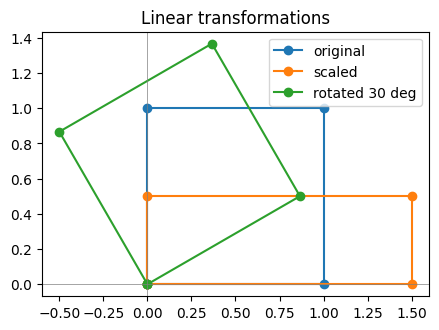

In [37]:
# -----------------------------------------------------------
# 🔹 4B. PLOT ORIGINAL vs TRANSFORMED
# -----------------------------------------------------------

def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(square),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

Rotated corners: 
 [[ 0.     0.707 -0.354]
 [ 0.     0.707  1.061]]


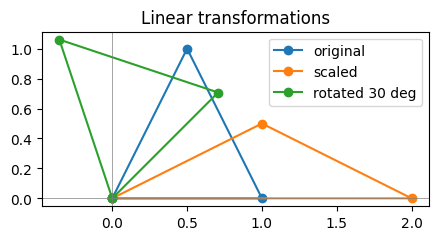

In [52]:

tri = np.array([[0, 1, 0.5],
                [0, 0, 1.0]])   # 3 corners of a triangle

# 1. Scaling matrix (x*2, y*0.5)
# YOUR CODE HERE
S = np.array([[2.0, 0.0],
              [0.0, 0.5]])
# 2. Rotation matrix (45 degrees)
# YOUR CODE HERE
theta = np.deg2rad(45)

R = np.array([[np.cos(theta), -np.sin(theta)],
              [np.sin(theta),  np.cos(theta)]])
scaled = S @ tri
rotated = R @ tri
print('Rotated corners: \n', rotated)

# 3. Apply both and plot original vs transformed
# YOUR CODE HERE
def close_loop(pts):
    # repeat the first point at the end so the polygon closes
    return np.hstack([pts, pts[:, :1]])

fig, ax = plt.subplots(figsize=(5, 5))
ax.plot(*close_loop(tri),  marker='o', label='original')
ax.plot(*close_loop(scaled),  marker='o', label='scaled')
ax.plot(*close_loop(rotated), marker='o', label='rotated 30 deg')
ax.axhline(0, color='gray', lw=0.5); ax.axvline(0, color='gray', lw=0.5)
ax.set_aspect('equal'); ax.legend(); ax.set_title('Linear transformations')
plt.show()

In [41]:
# -----------------------------------------------------------
# 🔹 5A. COMPUTE EIGENVALUES & EIGENVECTORS
# -----------------------------------------------------------

A = np.array([[2., 0.],
              [0., 3.]])

vals, vecs = la.eig(A)     # vals = eigenvalues, vecs columns = eigenvectors
print('Eigenvalues  (lambda):', vals)
print('Eigenvectors (columns):\n', vecs)


# -----------------------------------------------------------
# 🔹 5B. VERIFY  A v = lambda v
# -----------------------------------------------------------

for i in range(len(vals)):
    v = vecs[:, i]                 # i-th eigenvector
    lhs = A @ v                    # A v
    rhs = vals[i] * v              # lambda v
    print(f'lambda={vals[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))

Eigenvalues  (lambda): [2. 3.]
Eigenvectors (columns):
 [[1. 0.]
 [0. 1.]]
lambda=2.0  A v == lambda v ? True
lambda=3.0  A v == lambda v ? True


In [55]:
C = np.array([[4., 1.],
              [2., 3.]])

# 1. eigenvalues and eigenvectors
# YOUR CODE HERE
eigenvalues, eigenvectors = la.eig(C)
# 2. print eigenvalues
# YOUR CODE HERE
print('Eigenvalues  (lambda):', eigenvalues)
print('Eigenvectors (columns):\n', eigenvectors)

# 3. verify A v = lambda v for the first eigenvector
# YOUR CODE HERE
for i in range(len(eigenvalues)):
    v = eigenvectors[:, i]                 # i-th eigenvector
    lhs = C @ v                    # A v
    rhs = eigenvalues[i] * v              # lambda v
    print(f'lambda={eigenvalues[i]:.1f}  A v == lambda v ?', np.allclose(lhs, rhs))


Eigenvalues  (lambda): [5. 2.]
Eigenvectors (columns):
 [[ 0.707 -0.447]
 [ 0.707  0.894]]
lambda=5.0  A v == lambda v ? True
lambda=2.0  A v == lambda v ? True


In [56]:
# -----------------------------------------------------------
# 🔹 6A. SOLVE A 3x3 SYSTEM  A x = b
# -----------------------------------------------------------

A = np.array([[ 2.,  1., -1.],
              [-3., -1.,  2.],
              [-2.,  1.,  2.]])
b = np.array([8., -11., -3.])

x = la.solve(A, b)
print('Solution x:', x)                    # [2, 3, -1]
print('Rank of A :', la.matrix_rank(A))     # 3 -> full rank
print('Full rank -> a unique solution exists')


Solution x: [ 2.  3. -1.]
Rank of A : 3
Full rank -> a unique solution exists


In [57]:

# -----------------------------------------------------------
# 🔹 6B. RANK TELLS YOU SOLVABILITY
# -----------------------------------------------------------

# A rank-deficient matrix: row 3 = row 1 + row 2 (not independent)
D = np.array([[1., 2., 3.],
              [4., 5., 6.],
              [5., 7., 9.]])
print('Rank of D:', la.matrix_rank(D), '-> < 3, so rows are dependent')

Rank of D: 2 -> < 3, so rows are dependent


In [58]:
# -----------------------------------------------------------
# 🔹 6C. COSINE SIMILARITY ON 'EMBEDDINGS'
# -----------------------------------------------------------

# Toy 4-D embeddings (in practice these come from a model)
king  = np.array([0.8, 0.6, 0.1, 0.2])
queen = np.array([0.7, 0.7, 0.1, 0.3])
apple = np.array([0.1, 0.0, 0.9, 0.8])

print('cosine(king, queen):', round(cosine(king, queen), 3))   # high
print('cosine(king, apple):', round(cosine(king, apple), 3))   # low

cosine(king, queen): 0.986
cosine(king, apple): 0.267


In [65]:
A2 = np.array([[3., 2.],
               [1., 4.]])
b2 = np.array([7., 9.])

cat = np.array([0.9, 0.8, 0.1])
dog = np.array([0.85, 0.7, 0.2])
car = np.array([0.1, 0.2, 0.95])

# 1. Solve A2 x = b2
# YOUR CODE HERE
x = la.solve(A2, b2)
print('Solution x:', x)                    # [1, 2, -1]

# 2. Rank of A2
# YOUR CODE HERE
print('Rank of A2 :', la.matrix_rank(A2))     # 2 -> full rank
# 3. cosine(cat, dog) and cosine(cat, car); which is more similar?
# YOUR CODE HERE
print('cosine(cat, dog):', round(cosine(cat, dog), 3))   # high
print('cosine(cat, car):', round(cosine(cat, car), 3))   #low

Solution x: [1. 2.]
Rank of A2 : 2
cosine(cat, dog): 0.995
cosine(cat, car): 0.293
